In [7]:
import numpy as np 
import matplotlib.pyplot as plt 
import tensorflow as tf
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras import Sequential
from tensorflow.keras.losses import MeanSquaredError, BinaryCrossentropy
from tensorflow.keras.activations import sigmoid
import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR) 
tf.autograph.set_verbosity(0)

## Neurons without activation - Regression/Linear Model

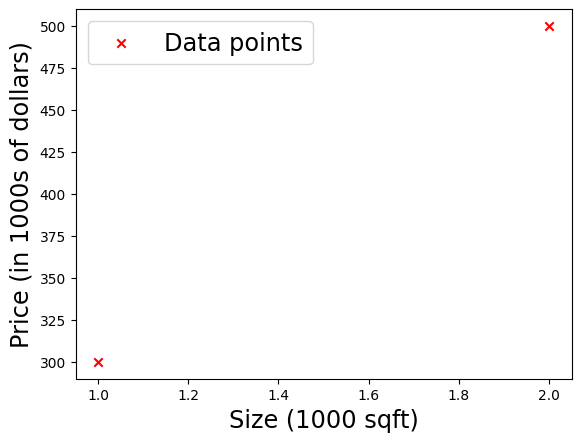

In [11]:
X_train = np.array([[1.0], [2.0]], dtype = np.float32)
Y_train = np.array([[300], [500]], dtype = np.float32)

fig, ax = plt.subplots(1, 1)
ax.scatter(X_train, Y_train, marker='x', c='r', label="Data points") 
ax.legend(fontsize='xx-large') 
ax.set_ylabel('Price (in 1000s of dollars)', fontsize='xx-large') 
ax.set_xlabel('Size (1000 sqft)', fontsize = 'xx-large') 
plt.show()

### Regression/Linear Model

The function implemented by a neuron with no activation is the same as in Course 1, linear regression: 
    $$f_{w, b}(x^{(i)}) = \mathbf{w}\cdot x^{(i)} + b \tag{1}$$

We can define a layer with one neuron or unit and compare it to the familiar linear regression function 

In [12]:
linear_layer = tf.keras.layers.Dense(units = 1, activation='linear',)

In [13]:
linear_layer.get_weights()

[]

There are no weights as the weights are not yet insantiated. Let's try the model on one example in `X_train`. This will trigger the instantiation of the weights. Note, the input to the layer must be 2D, so we'll reshape it

In [21]:
a1 = linear_layer(X_train[0].reshape(1, 1))
print(a1)

tf.Tensor([[0.2441647]], shape=(1, 1), dtype=float32)


In [22]:
w, b = linear_layer.get_weights()
print(f"w = {w}, b = {b}")

w = [[0.2441647]], b = [0.]


A linear regression model (1) with a single input feature will have a single weight and bias. This matches the dimensions of our `linear layer` above. The weights are initialized to random values so let's set them to some known values

In [23]:
set_w = np.array([[200]])
set_b = np.array([100])

linear_layer.set_weights([set_w, set_b])
print(linear_layer.get_weights())

[array([[200.]], dtype=float32), array([100.], dtype=float32)]


In [25]:
a1 = linear_layer(X_train[0].reshape(1, 1))
print(a1)
alin = np.dot(set_w, X_train[0].reshape(1, 1)) + set_b
print(alin)

tf.Tensor([[300.]], shape=(1, 1), dtype=float32)
[[300.]]


In [28]:
prediction_tf = linear_layer(X_train)
prediction_np = np.dot(X_train, set_w) + set_b

## Neuron with sigmoid activation

The function implemented by a neuron/unit with a sigmoid activation is the same as in Course 1, logistic regression: 
    $$f_{w, b}(x^{(i)}) = g(\mathbf{w}x^{(i)} + b)$$
where 
    $$g(x) = sigmoid(x)$$

In [31]:
X_train = np.array([0., 1, 2, 3, 4, 5], dtype=np.float32).reshape(-1,1)  # 2-D Matrix
Y_train = np.array([0,  0, 0, 1, 1, 1], dtype=np.float32).reshape(-1,1)  # 2-D Matrix

### Logistic Neuron 

We can implement a 'logistic neuron' by adding a sigmoid activation.

In [47]:
model = Sequential (
    [
        tf.keras.layers.Dense(1, input_dim = 1, activation = 'sigmoid', name = 'L1')
    ]
)

In [34]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ L1 (Dense)                      │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

In [39]:
logistic_layer = model.get_layer('L1')
w, b = logistic_layer.get_weights()
print(w, b)
print(w.shape, b.shape)

[[-0.31520498]] [0.]
(1, 1) (1,)


In [40]:
set_w = np.array([[2]])
set_b = np.array([-4.5])
logistic_layer.set_weights([set_w, set_b])
print(logistic_layer.get_weights())

[array([[2.]], dtype=float32), array([-4.5], dtype=float32)]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
[[0.01098694]]
